In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
from matplotlib.colors import ListedColormap, BoundaryNorm

# === Folder path ===
folder_path = '/content/drive/MyDrive/BratsDataset/data'

# === Helper: Combine one-hot mask channels into single label map ===
def combine_mask_channels(mask):
    combined = np.zeros(mask.shape[:2], dtype=np.uint8)
    combined[mask[:, :, 0] == 1] = 1  # Tumor Core (NCR/NET)
    combined[mask[:, :, 1] == 1] = 2  # Edema (ED)
    combined[mask[:, :, 2] == 1] = 4  # Enhancing Tumor (ET)
    return combined

# === Helper: normalize image channels ===
def normalize_images(image):
    normalized = []
    for i in range(image.shape[-1]):
        img = image[:, :, i].astype(np.float32)
        if img.max() != img.min():
            img = (img - img.min()) / (img.max() - img.min())
        else:
            img = np.zeros_like(img)
        normalized.append(img)
    return normalized

# === Visualization function ===
def display_volume(volume_num, slice_num):
    filename = f"volume_{volume_num}_slice_{slice_num}.h5"
    file_path = os.path.join(folder_path, filename)

    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        return

    with h5py.File(file_path, 'r') as f:
        image = f['image'][:]
        mask = f['mask'][:]

    combined_mask = combine_mask_channels(mask)
    normalized_images = normalize_images(image)

    # Custom colormap
    colors = ['black', 'red', 'green', 'black', 'blue']
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(boundaries=[-0.5,0.5,1.5,2.5,3.5,4.5], ncolors=cmap.N)

    # Plot
    modality_names = ['T1', 'T1Gd', 'T2', 'FLAIR']
    plt.figure(figsize=(20, 5))

    # Show modalities
    for i, mod in enumerate(modality_names):
        plt.subplot(1, 6, i+1)
        plt.imshow(normalized_images[i], cmap='gray')
        plt.title(mod)
        plt.axis('off')

    # Show FLAIR + mask overlay
    plt.subplot(1, 6, 5)
    plt.imshow(normalized_images[3], cmap='gray')
    plt.title('FLAIR')
    plt.axis('off')

    plt.subplot(1, 6, 6)
    plt.imshow(normalized_images[3], cmap='gray')
    im = plt.imshow(combined_mask, cmap=cmap, norm=norm, alpha=0.6)
    plt.title('FLAIR + Mask')
    plt.axis('off')

    cbar = plt.colorbar(im, ticks=[0,1,2,4])
    cbar.ax.set_yticklabels(['Background', 'NCR/NET', 'Edema', 'Enhancing Tumor'])

    plt.tight_layout()
    plt.show()

# === Interactive sliders ===
volume_input = widgets.BoundedIntText(value=1, min=1, max=369, description='Volume:')
slice_input = widgets.BoundedIntText(value=70, min=0, max=154, description='Slice:')

widgets.interact(display_volume, volume_num=volume_input, slice_num=slice_input)


interactive(children=(BoundedIntText(value=1, description='Volume:', max=369, min=1), BoundedIntText(value=70,…

<function __main__.display_volume(volume_num, slice_num)>

In [ ]:
import h5py
import os

folder_path = '/content/drive/MyDrive/BratsDataset/data'
files = [f for f in os.listdir(folder_path) if f.endswith('.h5')]

h5_file_path = os.path.join(folder_path, files[0])

with h5py.File(h5_file_path, 'r') as f:
    print("Top-level keys:", list(f.keys()))
    print("File-level attributes:")
    for k, v in f.attrs.items():
        print(f"  {k}: {v}")


Top-level keys: ['image', 'mask']
File-level attributes:


In [ ]:
import h5py
import numpy as np
import os

# Pick a sample file
file_path = '/content/drive/MyDrive/BratsDataset/data/volume_1_slice_70.h5'

with h5py.File(file_path, 'r') as f:
    # List all datasets
    print("Keys in HDF5 file:", list(f.keys()))

    # Load datasets
    image = f['image'][:]
    mask = f['mask'][:]

    # Inspect shapes and types
    print("Image shape:", image.shape)
    print("Image dtype:", image.dtype)
    print("Image min/max:", image.min(), image.max())

    print("Mask shape:", mask.shape)
    print("Mask dtype:", mask.dtype)
    print("Mask min/max:", mask.min(), mask.max())

    # Check unique values in mask
    if mask.ndim == 3:
        print("Mask unique values per channel:")
        for i in range(mask.shape[-1]):
            print(f"Channel {i}: {np.unique(mask[:,:,i])}")


Keys in HDF5 file: ['image', 'mask']
Image shape: (240, 240, 4)
Image dtype: float64
Image min/max: -0.6357062147562488 7.480161776552308
Mask shape: (240, 240, 3)
Mask dtype: uint8
Mask min/max: 0 1
Mask unique values per channel:
Channel 0: [0 1]
Channel 1: [0 1]
Channel 2: [0 1]


In [ ]:
import os
import h5py
import numpy as np
import cv2
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
from functools import partial


raw_data_dir = '/content/drive/MyDrive/BratsDataset/data'
output_dir = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
log_file = os.path.join(output_dir, 'preprocessed_log.txt')
failed_log = os.path.join(output_dir, 'failed_log.txt')

os.makedirs(output_dir, exist_ok=True)

target_shape = (240, 240)  # H, W


def normalize_slice(img):
    """Normalize image to zero mean, unit std."""
    mean = np.mean(img)
    std = np.std(img)
    return ((img - mean) / (std + 1e-8)).astype(np.float32)

def onehot_to_single_channel(mask):
    """Convert one-hot mask (H,W,3) to single-channel {0,1,2,3}."""
    single = np.zeros(mask.shape[:2], dtype=np.uint8)
    single[mask[:,:,0] == 1] = 1  # Tumor Core
    single[mask[:,:,1] == 1] = 2  # Edema
    single[mask[:,:,2] == 1] = 3  # Enhancing Tumor
    return single

def resize_image(img, shape):
    return cv2.resize(img, shape[::-1], interpolation=cv2.INTER_AREA)

def resize_mask(mask, shape):
    return cv2.resize(mask, shape[::-1], interpolation=cv2.INTER_NEAREST)

def preprocess_file(fname, input_folder, output_folder):
    try:
        file_path = os.path.join(input_folder, fname)
        out_file = os.path.join(output_folder, f'preprocessed_{fname}')

        with h5py.File(file_path, 'r') as f:
            image = f['image'][:]
            mask = f['mask'][:]

        image_norm = np.stack([normalize_slice(image[:,:,i]) for i in range(image.shape[-1])], axis=-1)
        image_resized = np.stack([resize_image(image_norm[:,:,i], target_shape) for i in range(image.shape[-1])], axis=-1)

        # Convert mask to single-channel & resize
        mask_single = onehot_to_single_channel(mask)
        mask_resized = resize_mask(mask_single, target_shape)

        # Save preprocessed file
        with h5py.File(out_file, 'w') as f:
            f.create_dataset('image', data=image_resized, compression='lzf')
            f.create_dataset('mask', data=mask_resized, compression='lzf')

        return fname, True, ""
    except Exception as e:
        return fname, False, str(e)

def load_log(log_path):
    return set(open(log_path).read().splitlines()) if os.path.exists(log_path) else set()

def update_logs(results):
    with open(log_file, 'a') as log, open(failed_log, 'a') as fail:
        for fname, success, error in results:
            if success:
                log.write(fname + '\n')
            else:
                fail.write(f"{fname}\t{error}\n")

def process_batch(file_batch):
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        fn = partial(preprocess_file, input_folder=raw_data_dir, output_folder=output_dir)
        results = list(tqdm(executor.map(fn, file_batch), total=len(file_batch)))
    update_logs(results)


all_files = sorted([f for f in os.listdir(raw_data_dir) if f.endswith('.h5')])
done_files = load_log(log_file)
to_process = [f for f in all_files if f not in done_files]

batch_size = 2000
for i in range(0, len(to_process), batch_size):
    batch = to_process[i:i+batch_size]
    print(f"\n🚀 Processing batch {i} to {i + len(batch)}")
    process_batch(batch)

print("\n✅ Preprocessing complete! Files saved in:", output_dir)



🚀 Processing batch 0 to 2000


100%|██████████| 2000/2000 [08:17<00:00,  4.02it/s]


🚀 Processing batch 2000 to 4000



100%|██████████| 2000/2000 [06:23<00:00,  5.21it/s]


🚀 Processing batch 4000 to 6000


...


🚀 Processing batch 54000 to 56000


100%|██████████| 2000/2000 [06:01<00:00,  5.53it/s]


🚀 Processing batch 56000 to 57205



100%|██████████| 1205/1205 [03:34<00:00,  5.61it/s]


✅ Preprocessing complete! Files saved in: /content/drive/MyDrive/BratsDataset/testing/processed_data


In [ ]:
#view data after preprocessing
import h5py
import numpy as np
import os

preprocessed_file = '/content/drive/MyDrive/BratsDataset/testing/processed_data/preprocessed_volume_1_slice_70.h5'

if not os.path.exists(preprocessed_file):
    print("File not found:", preprocessed_file)
else:
    with h5py.File(preprocessed_file, 'r') as f:
        image = f['image'][:]
        mask = f['mask'][:]

    print("✅ Preprocessed file loaded:", preprocessed_file)
    print("Image shape:", image.shape)
    print("Image dtype:", image.dtype)
    print("Image min/max:", image.min(), image.max())

    print("Mask shape:", mask.shape)
    print("Mask dtype:", mask.dtype)
    print("Mask min/max:", mask.min(), mask.max())
    print("Unique labels in mask:", np.unique(mask))


✅ Preprocessed file loaded: /content/drive/MyDrive/BratsDataset/testing/processed_data/preprocessed_volume_1_slice_70.h5
Image shape: (240, 240, 4)
Image dtype: float32
Image min/max: -0.6357062 7.4801617
Mask shape: (240, 240)
Mask dtype: uint8
Mask min/max: 0 3
Unique labels in mask: [0 1 2 3]


Image shape: (240, 240, 4), Mask shape: (240, 240)
Mask unique labels: [0 1 2 3]


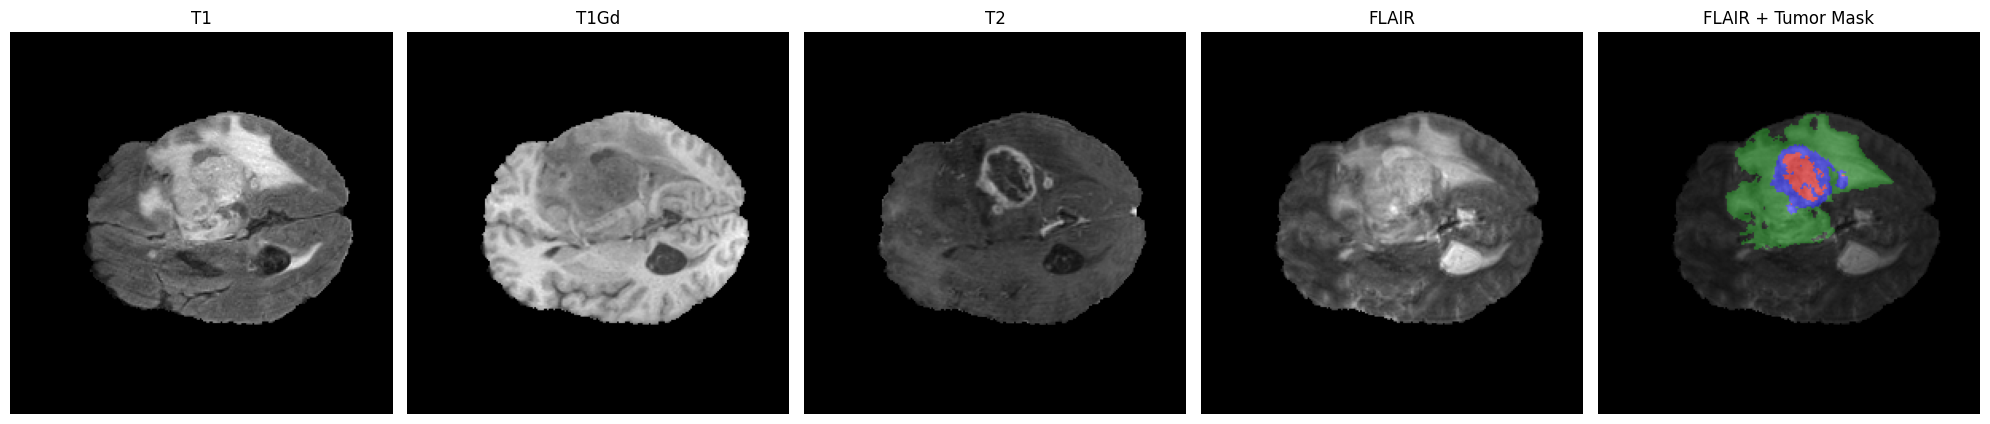

In [ ]:
#view all modality and mask overlay on flair modality
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

file_path = '/content/drive/MyDrive/BratsDataset/testing/processed_data/preprocessed_volume_1_slice_70.h5'

with h5py.File(file_path, 'r') as f:
    image = f['image'][:]  # (H, W, 4)
    mask = f['mask'][:]    # (H, W) single-channel

print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
print(f"Mask unique labels: {np.unique(mask)}")

colors = ['black', 'red', 'green', 'blue']  #0=bg, 1=TC, 2=ED, 3=ET
cmap = ListedColormap(colors)

modality_names = ['T1', 'T1Gd', 'T2', 'FLAIR']

plt.figure(figsize=(20, 5))

for i in range(4):
    plt.subplot(1, 5, i+1)
    plt.imshow(image[:, :, i], cmap='gray')
    plt.title(modality_names[i])
    plt.axis('off')

# Show FLAIR + mask overlay
plt.subplot(1, 5, 5)
plt.imshow(image[:, :, 3], cmap='gray')  # FLAIR
plt.imshow(mask, cmap=cmap, alpha=0.5)   # Overlay mask
plt.title('FLAIR + Tumor Mask')
plt.axis('off')

plt.tight_layout()
plt.show()


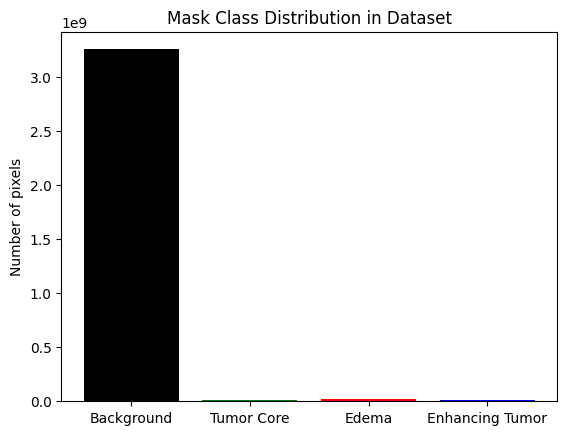

In [ ]:
import os, h5py, numpy as np
from collections import Counter
import matplotlib.pyplot as plt

folder = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
files = [f for f in os.listdir(folder) if f.endswith('.h5')]

label_counts = Counter()

for f in files:
    with h5py.File(os.path.join(folder, f), 'r') as h:
        mask = h['mask'][:]
        unique = np.unique(mask)
        for u in unique:
            label_counts[u] += np.sum(mask == u)

# Bar plot
plt.bar(label_counts.keys(), label_counts.values(), color=['black','red','green','blue'])
plt.xticks([0,1,2,3], ['Background','Tumor Core','Edema','Enhancing Tumor'])
plt.ylabel('Number of pixels')
plt.title('Mask Class Distribution in Dataset')
plt.show()


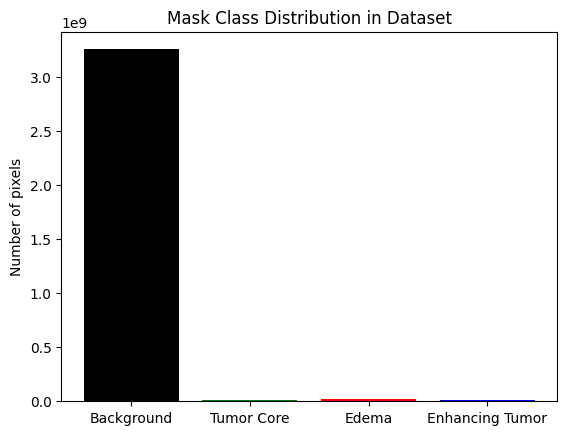


📊 Pixel Count Summary:
Class 0 (Background): 3,258,274,431 pixels (98.8852%)
Class 1 (Tumor Core): 8,162,653 pixels (0.2477%)
Class 2 (Edema): 21,302,506 pixels (0.6465%)
Class 3 (Enhancing Tumor): 7,268,410 pixels (0.2206%)


In [ ]:
import os, h5py, numpy as np
from collections import Counter
import matplotlib.pyplot as plt

folder = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
files = [f for f in os.listdir(folder) if f.endswith('.h5')]

label_counts = Counter()

for f in files:
    with h5py.File(os.path.join(folder, f), 'r') as h:
        mask = h['mask'][:]
        unique = np.unique(mask)
        for u in unique:
            label_counts[u] += np.sum(mask == u)

# Bar plot
plt.bar(label_counts.keys(), label_counts.values(), color=['black','red','green','blue'])
plt.xticks([0,1,2,3], ['Background','Tumor Core','Edema','Enhancing Tumor'])
plt.ylabel('Number of pixels')
plt.title('Mask Class Distribution in Dataset')
plt.show()

# --- Print exact counts and percentages ---
total_pixels = sum(label_counts.values())
print("\n📊 Pixel Count Summary:")
for k in sorted(label_counts.keys()):
    name = ['Background','Tumor Core','Edema','Enhancing Tumor'][k]
    count = label_counts[k]
    percent = 100 * count / total_pixels
    print(f"Class {k} ({name}): {count:,} pixels ({percent:.4f}%)")


In [ ]:
#saving data after splitting
import os
from collections import defaultdict
from sklearn.model_selection import train_test_split

data_dir = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
all_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.h5')])

volume_to_slices = defaultdict(list)
for fname in all_files:
    volume_id = '_'.join(fname.split('_')[1:3])
    volume_to_slices[volume_id].append(fname)

volume_ids = list(volume_to_slices.keys())

train_ids, temp_ids = train_test_split(volume_ids, test_size=0.2, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

train_files = [f for v in train_ids for f in volume_to_slices[v]]
val_files = [f for v in val_ids for f in volume_to_slices[v]]
test_files = [f for v in test_ids for f in volume_to_slices[v]]

save_dir = '/content/drive/MyDrive/BratsDataset/testing/splits'
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, "train_files.txt"), "w") as f:
    f.writelines(f"{x}\n" for x in train_files)

with open(os.path.join(save_dir, "val_files.txt"), "w") as f:
    f.writelines(f"{x}\n" for x in val_files)

with open(os.path.join(save_dir, "test_files.txt"), "w") as f:
    f.writelines(f"{x}\n" for x in test_files)

print(f"Total volumes: {len(volume_ids)}")
print(f"Train volumes: {len(train_ids)}")
print(f"Validation volumes: {len(val_ids)}")
print(f"Test volumes: {len(test_ids)}")

print(f"\nTrain slices: {len(train_files)}")
print(f"Validation slices: {len(val_files)}")
print(f"Test slices: {len(test_files)}")
print(f"\nSplit file lists saved in: {save_dir}")


Total volumes: 369
Train volumes: 295
Validation volumes: 37
Test volumes: 37

Train slices: 45735
Validation slices: 5735
Test slices: 5735

Split file lists saved in: /content/drive/MyDrive/BratsDataset/testing/splits


In [ ]:
#dataset class
import os
import h5py
import torch
from torch.utils.data import Dataset
import numpy as np

class BraTSSliceDataset(Dataset):
    def __init__(self, file_list_path, data_dir, transform=None):
        with open(file_list_path, 'r') as f:
            self.file_list = [line.strip() for line in f.readlines()]
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]
        file_path = os.path.join(self.data_dir, file_name)

        with h5py.File(file_path, 'r') as f:
            image = f['image'][:]
            mask = f['mask'][:]

        image = image.transpose(2, 0, 1)  # (C, H, W)

        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).long()

        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask


In [ ]:
#creatid data loaders
from torch.utils.data import DataLoader

data_dir = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
train_list = '/content/drive/MyDrive/BratsDataset/testing/splits/train_files.txt'
val_list   = '/content/drive/MyDrive/BratsDataset/testing/splits/val_files.txt'
test_list  = '/content/drive/MyDrive/BratsDataset/testing/splits/test_files.txt'
train_dataset = BraTSSliceDataset(train_list, data_dir)
val_dataset   = BraTSSliceDataset(val_list, data_dir)
test_dataset  = BraTSSliceDataset(test_list, data_dir)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

for images, masks in train_loader:
    print(images.shape, masks.shape)
    break


torch.Size([8, 4, 240, 240]) torch.Size([8, 240, 240])


In [ ]:
# calculate weights based on pixel count for each class
import os
import h5py
import numpy as np
from collections import Counter
from tqdm import tqdm

data_dir = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
train_list_path = '/content/drive/MyDrive/BratsDataset/testing/splits/train_files.txt'

with open(train_list_path, 'r') as f:
    train_files = [line.strip() for line in f.readlines()]

# Count pixels per class
class_pixel_counts = Counter()

for f in tqdm(train_files, desc="Counting pixels in training set"):
    path = os.path.join(data_dir, f)
    with h5py.File(path, 'r') as hf:
        mask = np.array(hf['mask'])
        classes, counts = np.unique(mask, return_counts=True)
        for cls, cnt in zip(classes, counts):
            class_pixel_counts[int(cls)] += int(cnt)

print("\nPixel counts per class in training set:")
for cls in sorted(class_pixel_counts.keys()):
    print(f"  Class {cls}: {class_pixel_counts[cls]} pixels")

# Compute class weights for CrossEntropyLoss
total_pixels = sum(class_pixel_counts.values())
class_weights = {
    cls: total_pixels / (len(class_pixel_counts) * cnt)
    for cls, cnt in class_pixel_counts.items()
}

print("\nClass weights for training:")
for cls in sorted(class_weights.keys()):
    print(f"  Class {cls}: {class_weights[cls]:.4f}")

# Convert to PyTorch tensor for CrossEntropyLoss
import torch
weights_tensor = torch.tensor([class_weights[i] for i in range(len(class_weights))], dtype=torch.float32)
print("\nPyTorch weights tensor:", weights_tensor)


Counting pixels in training set: 100%|██████████| 45735/45735 [09:02<00:00, 84.27it/s]



Pixel counts per class in training set:
  Class 0: 2604801980 pixels
  Class 1: 6423330 pixels
  Class 2: 17186081 pixels
  Class 3: 5924609 pixels

Class weights for training:
  Class 0: 0.2528
  Class 1: 102.5300
  Class 2: 38.3208
  Class 3: 111.1608

PyTorch weights tensor: tensor([  0.2528, 102.5300,  38.3208, 111.1608])


In [ ]:
#save weight for future use
import torch

torch.save(weights_tensor, "/content/drive/MyDrive/BratsDataset/testing/class_weights.pt")


In [ ]:
#load saved weight
weights_tensor = torch.load("/content/drive/MyDrive/BratsDataset/testing/class_weights.pt")
print("✅ Loaded weights:", weights_tensor)



✅ Loaded weights: tensor([  0.2528, 102.5300,  38.3208, 111.1608])


In [ ]:
import torch

def dice_score(preds, targets, num_classes=4, eps=1e-6):
    device = preds.device  # make everything live here

    preds = preds.to(device)
    targets = targets.to(device)

    dice_per_class = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).float()       # on device
        target_cls = (targets == cls).float()   # on device

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        if union == 0:
            # class not present -> define dice (you used 1.0; keep that if you want)
            dice = torch.tensor(1.0, device=device)
        else:
            dice = (2 * intersection + eps) / (union + eps)

        dice_per_class.append(dice)

    dice_per_class = torch.stack(dice_per_class)  # all on same device now
    mean_dice = dice_per_class.mean()
    return dice_per_class, mean_dice


In [ ]:
#CNN model
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, in_channels=4, out_channels=4):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.conv4(x)  # output logits per class
        return x


In [ ]:
#CNN  model
import torch
from torch.utils.data import DataLoader
import os
import json
from tqdm import tqdm
import numpy as np

data_dir = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
train_list = '/content/drive/MyDrive/BratsDataset/testing/splits/train_files.txt'
val_list   = '/content/drive/MyDrive/BratsDataset/testing/splits/val_files.txt'

checkpoint_dir = '/content/drive/MyDrive/BratsDataset/testing/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

best_model_path = os.path.join(checkpoint_dir, 'cnn_best.pth')
last_epoch_path = os.path.join(checkpoint_dir, 'cnn_last.pth')
history_file = os.path.join(checkpoint_dir, 'history.json')

batch_size = 8
num_epochs = 50
patience = 5
num_classes = 4

train_dataset = BraTSSliceDataset(train_list, data_dir)
val_dataset   = BraTSSliceDataset(val_list, data_dir)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(in_channels=4, out_channels=num_classes).to(device)

# Weighted CrossEntropyLoss
criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

start_epoch = 0
best_val_dice = 0.0

# Load best model
if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    best_val_dice = checkpoint['best_val_dice']
    print(f"Loaded best model with Val Dice={best_val_dice:.4f}")

# Load last epoch checkpoint
if os.path.exists(last_epoch_path):
    checkpoint = torch.load(last_epoch_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming training from epoch {start_epoch}")

# Load or initialize training history
if os.path.exists(history_file):
    with open(history_file, 'r') as f:
        history = json.load(f)
else:
    history = {'train_loss': [], 'val_loss': [], 'val_mean_dice': [], 'val_dice_per_class': []}

epochs_no_improve = 0

for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f"[Epoch {epoch+1}] Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    val_dice_sum = torch.zeros(num_classes, device=device)

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"[Epoch {epoch+1}] Validation"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            dice_per_class, mean_dice = dice_score(preds, masks, num_classes=num_classes)
            val_dice_sum += dice_per_class.to(device)

    val_loss /= len(val_loader)
    val_dice_avg = (val_dice_sum / len(val_loader)).cpu().tolist()
    mean_val_dice = np.mean(val_dice_avg)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} "
          f"- Val Loss: {val_loss:.4f} - Val Mean Dice: {mean_val_dice:.4f} "
          f"- Per Class Dice: {val_dice_avg}")

    #  Update history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mean_dice'].append(mean_val_dice)
    history['val_dice_per_class'].append(val_dice_avg)
    with open(history_file, 'w') as f:
        json.dump(history, f)

    # Save best model
    if mean_val_dice > best_val_dice:
        best_val_dice = mean_val_dice
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_dice': best_val_dice
        }, best_model_path)
        print("✅ Best model updated and saved.")
    else:
        epochs_no_improve += 1

    # Save last epoch checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_dice': best_val_dice
    }, last_epoch_path)

    #  Early stopping point
    if epochs_no_improve >= patience:
        print("⚠️ Early stopping triggered.")
        break


Loaded best model with Val Dice=0.3832
Resuming training from epoch 15


[Epoch 16] Validation: 100%|██████████| 717/717 [00:58<00:00, 12.31it/s]


Epoch 16/50 - Train Loss: 0.3361 - Val Loss: 0.2816 - Val Mean Dice: 0.3493 - Per Class Dice: [0.974518895149231, 0.10587496310472488, 0.17352673411369324, 0.14335153996944427]


[Epoch 17] Validation: 100%|██████████| 717/717 [00:59<00:00, 12.02it/s]


Epoch 17/50 - Train Loss: 0.3361 - Val Loss: 0.2923 - Val Mean Dice: 0.3403 - Per Class Dice: [0.9688818454742432, 0.09939321875572205, 0.15370947122573853, 0.13936227560043335]


...

Epoch 18/50 - Train Loss: 0.3345 - Val Loss: 0.2765 - Val Mean Dice: 0.3563 - Per Class Dice: [0.9771106839179993, 0.1213708445429802, 0.1798744946718216, 0.14694511890411377]


[Epoch 19] Validation: 100%|██████████| 717/717 [00:59<00:00, 11.96it/s]


Epoch 19/50 - Train Loss: 0.3322 - Val Loss: 0.2481 - Val Mean Dice: 0.3715 - Per Class Dice: [0.9851415753364563, 0.12692619860172272, 0.20595687627792358, 0.16800177097320557]


[Epoch 20] Validation: 100%|██████████| 717/717 [00:58<00:00, 12.21it/s]

Epoch 20/50 - Train Loss: 0.3313 - Val Loss: 0.2594 - Val Mean Dice: 0.3609 - Per Class Dice: [0.9803574085235596, 0.11433754116296768, 0.19236451387405396, 0.1565689891576767]
⚠️ Early stopping triggered.


In [ ]:
#generate model summary
!pip install torchinfo
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(in_channels=4, out_channels=4).to(device)

summary(model, input_size=(1, 4, 240, 240))


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 4, 240, 240]          --
├─Conv2d: 1-1                            [1, 32, 240, 240]         1,184
├─BatchNorm2d: 1-2                       [1, 32, 240, 240]         64
├─Conv2d: 1-3                            [1, 64, 240, 240]         18,496
├─BatchNorm2d: 1-4                       [1, 64, 240, 240]         128
├─Conv2d: 1-5                            [1, 64, 240, 240]         36,928
├─BatchNorm2d: 1-6                       [1, 64, 240, 240]         128
├─Conv2d: 1-7                            [1, 4, 240, 240]          260
Total params: 57,188
Trainable params: 57,188
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 3.28
Input size (MB): 0.92
Forward/backward pass size (MB): 149.30
Params size (MB): 0.23
Estimated Total Size (MB): 150.45

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
}, 'cnn_best.pth')


In [ ]:
#load data from history json
import json
import os
import matplotlib.pyplot as plt
import numpy as np

checkpoint_dir = '/content/drive/MyDrive/BratsDataset/testing/checkpoints'
history_file = os.path.join(checkpoint_dir, 'history.json')

with open(history_file, 'r') as f:
    history = json.load(f)

train_loss = history['train_loss']
val_loss = history['val_loss']
val_mean_dice = history['val_mean_dice']
val_dice_per_class = np.array(history['val_dice_per_class'])  # shape: (epochs, num_classes)

epochs = range(1, len(train_loss) + 1)
print(f"Loaded history for {len(train_loss)} epochs.")


Loaded history for 20 epochs.


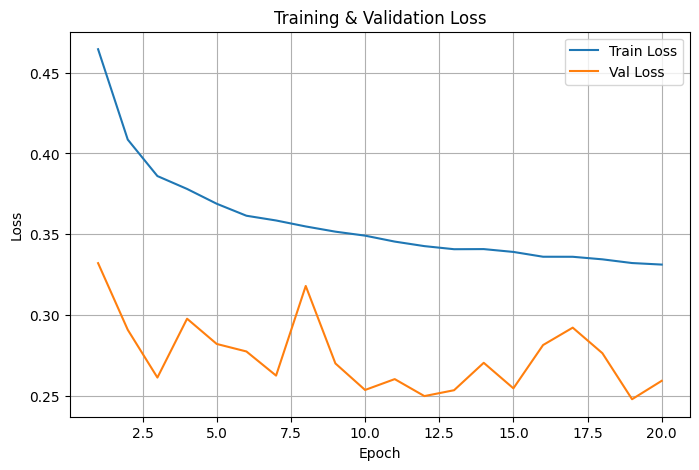

In [ ]:
#train vs val loss graph
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


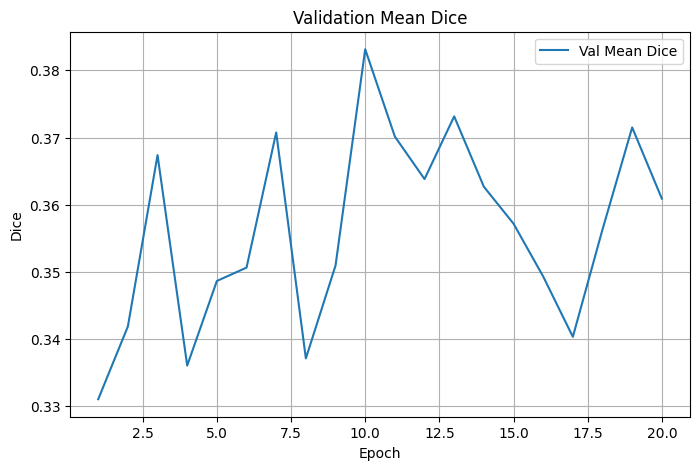

In [ ]:
#validation mean dice
plt.figure(figsize=(8,5))
plt.plot(epochs, val_mean_dice, label='Val Mean Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.title('Validation Mean Dice')
plt.legend()
plt.grid(True)
plt.show()


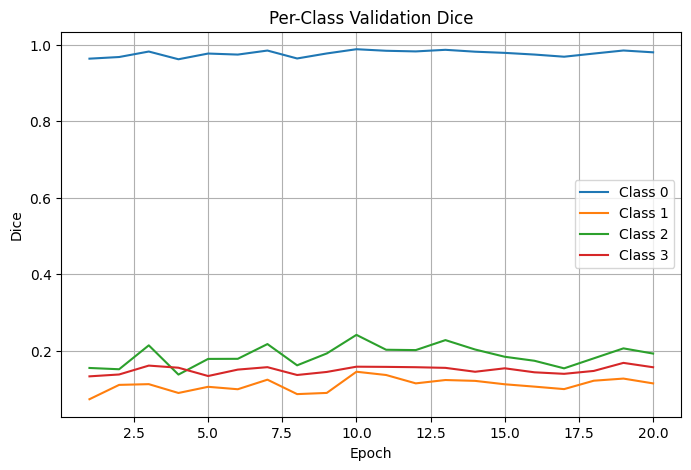

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(epochs, val_dice_per_class[:, 0], label='Class 0')
plt.plot(epochs, val_dice_per_class[:, 1], label='Class 1')
plt.plot(epochs, val_dice_per_class[:, 2], label='Class 2')
plt.plot(epochs, val_dice_per_class[:, 3], label='Class 3')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.title('Per-Class Validation Dice')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#loading test dataset
data_dir = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
test_list = '/content/drive/MyDrive/BratsDataset/testing/splits/test_files.txt'
test_dataset = BraTSSliceDataset(test_list, data_dir)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)


In [ ]:
#loading model
model = CNN(in_channels=4, out_channels=num_classes).to(device)

checkpoint = torch.load(best_model_path, weights_only=False, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model with Val Dice =", checkpoint['best_val_dice'])


KeyError: 'model_state_dict'

In [ ]:
#making model ready for testing
import torch
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 4

model = CNN(in_channels=4, out_channels=4).to(device)

checkpoint_dir = '/content/drive/MyDrive/BratsDataset/testing/checkpoints'
best_model_path = os.path.join(checkpoint_dir, 'cnn_best.pth')

checkpoint = torch.load(best_model_path, weights_only=False, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model with Val Dice =", checkpoint['best_val_dice'])

# same loss as training
criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor.to(device))


Loaded best model with Val Dice = 0.3831506557762623


In [ ]:
from tqdm import tqdm

model.eval()

test_loss = 0.0
test_dice = 0.0
num_batches = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        masks = masks.to(device).long()

        logits = model(images)
        loss = criterion(logits, masks)
        test_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        _, batch_mean_dice = dice_score(preds, masks, num_classes=num_classes)
        test_dice += batch_mean_dice.item()

        num_batches += 1

avg_test_loss = test_loss / num_batches
avg_test_dice = test_dice / num_batches

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Dice: {avg_test_dice:.4f}")


Testing: 100%|██████████| 717/717 [00:57<00:00, 12.55it/s]

Test Loss: 0.2255
Test Dice: 0.4014


Visualizing slice 3 with most image content...


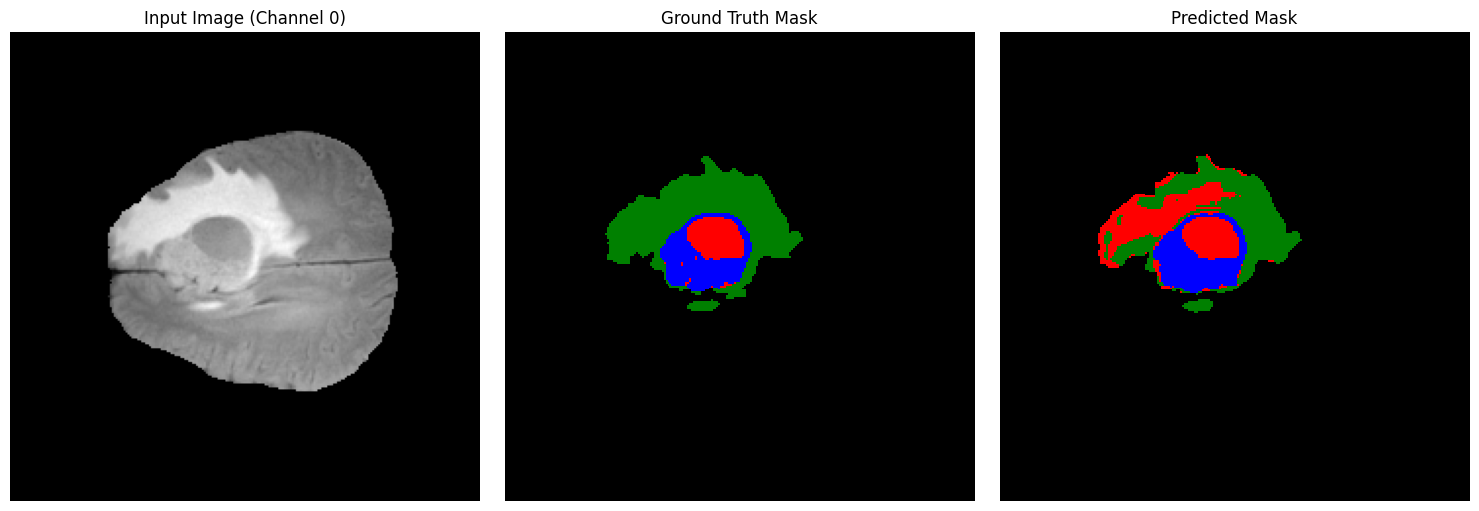

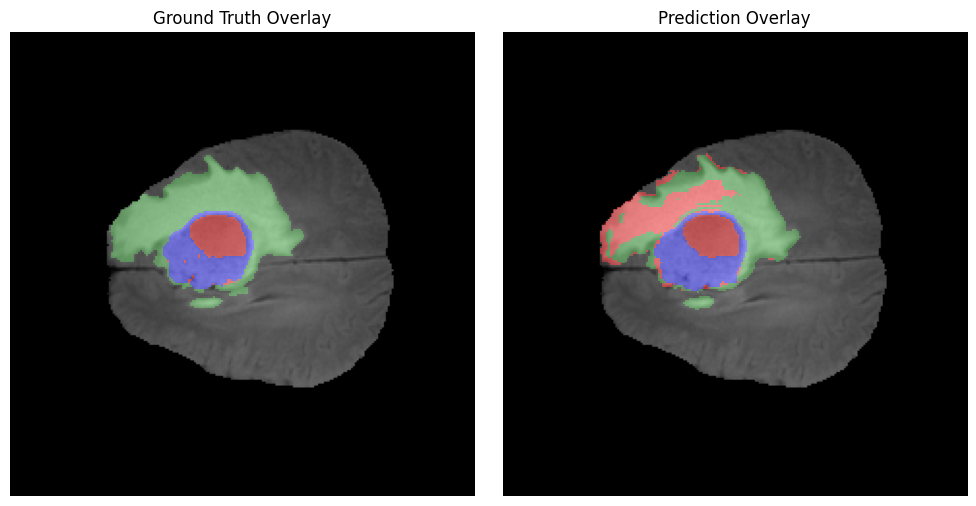

In [ ]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "black",
    "red",
    "green",
    "blue",
])

model.eval()

# Fetch a batch
images, masks = next(iter(test_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(images)
    preds = torch.argmax(logits, dim=1)

# Choose the slice with the most image content
intensity_sum = images[:, 0].abs().view(images.size(0), -1).sum(dim=1)
idx = torch.argmax(intensity_sum).item()

print(f"Visualizing slice {idx} with most image content...")

# Plot input, ground truth, and prediction
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Input image
axes[0].imshow(images[idx, 0].cpu(), cmap='gray')
axes[0].set_title("Input Image (Channel 0)")
axes[0].axis("off")

# Ground truth mask using custom colormap
axes[1].imshow(masks[idx].cpu(), cmap=cmap, interpolation='nearest')
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

# Prediction mask using custom colormap
axes[2].imshow(preds[idx].cpu(), cmap=cmap, interpolation='nearest')
axes[2].set_title("Predicted Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Overlay visualizations
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Overlay GT
axes[0].imshow(images[idx, 0].cpu(), cmap='gray')
axes[0].imshow(masks[idx].cpu(), cmap=cmap, alpha=0.4, interpolation='nearest')
axes[0].set_title("Ground Truth Overlay")
axes[0].axis("off")

# Overlay Prediction
axes[1].imshow(images[idx, 0].cpu(), cmap='gray')
axes[1].imshow(preds[idx].cpu(), cmap=cmap, alpha=0.4, interpolation='nearest')
axes[1].set_title("Prediction Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
#define functions for evaluation metrices
import torch

def segmentation_metrics(preds, targets, num_classes=4, eps=1e-6):
    """
    preds, targets: [B, H, W] with class indices
    returns: (dice, iou, precision, recall) each [num_classes]
    """

    device = preds.device
    preds = preds.to(device)
    targets = targets.to(device)

    dice = []
    iou = []
    precision = []
    recall = []

    # Flatten once for convenience
    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)

    for cls in range(num_classes):
        pred_cls = (preds_flat == cls)
        target_cls = (targets_flat == cls)

        tp = (pred_cls & target_cls).sum().float()
        fp = (pred_cls & ~target_cls).sum().float()
        fn = (~pred_cls & target_cls).sum().float()
        # tn not needed for these metrics

        # Dice
        dice_c = (2 * tp + eps) / (2 * tp + fp + fn + eps)
        dice.append(dice_c)

        # IoU
        iou_c = (tp + eps) / (tp + fp + fn + eps)
        iou.append(iou_c)

        # Precision
        prec_c = (tp + eps) / (tp + fp + eps)
        precision.append(prec_c)

        # Recall
        rec_c = (tp + eps) / (tp + fn + eps)
        recall.append(rec_c)

    dice = torch.stack(dice)         # [num_classes]
    iou = torch.stack(iou)
    precision = torch.stack(precision)
    recall = torch.stack(recall)

    return dice, iou, precision, recall


In [ ]:
from tqdm import tqdm

model.eval()

test_loss = 0.0
num_batches = 0

# accumulate sums per class
dice_sum = torch.zeros(num_classes, device=device)
iou_sum = torch.zeros(num_classes, device=device)
prec_sum = torch.zeros(num_classes, device=device)
recall_sum = torch.zeros(num_classes, device=device)

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        masks = masks.to(device).long()

        logits = model(images)
        loss = criterion(logits, masks)
        test_loss += loss.item()

        preds = torch.argmax(logits, dim=1)   # [B, H, W]

        # compute per-class metrics for this batch
        dice_b, iou_b, prec_b, recall_b = segmentation_metrics(
            preds, masks, num_classes=num_classes
        )

        dice_sum += dice_b
        iou_sum += iou_b
        prec_sum += prec_b
        recall_sum += recall_b

        num_batches += 1

# average over batches
avg_test_loss = test_loss / num_batches
dice_avg = (dice_sum / num_batches).cpu()
iou_avg = (iou_sum / num_batches).cpu()
prec_avg = (prec_sum / num_batches).cpu()
recall_avg = (recall_sum / num_batches).cpu()

print(f"\nTest Loss: {avg_test_loss:.4f}")
print("Per-class metrics:")

for c in range(num_classes):
    print(f"Class {c}: "
          f"Dice={dice_avg[c]:.4f}, "
          f"IoU={iou_avg[c]:.4f}, "
          f"Precision={prec_avg[c]:.4f}, "
          f"Recall={recall_avg[c]:.4f}")

# overall (mean over classes)
print("\nMean over classes:")
print(f"Dice     : {dice_avg.mean():.4f}")
print(f"IoU      : {iou_avg.mean():.4f}")
print(f"Precision: {prec_avg.mean():.4f}")
print(f"Recall   : {recall_avg.mean():.4f}")


Testing: 100%|██████████| 717/717 [00:55<00:00, 12.88it/s]


Test Loss: 0.2255
Per-class metrics:
Class 0: Dice=0.9885, IoU=0.9775, Precision=0.9996, Recall=0.9779
Class 1: Dice=0.1330, IoU=0.0994, Precision=0.1184, Recall=0.8141
Class 2: Dice=0.2709, IoU=0.2069, Precision=0.2318, Recall=0.8851
Class 3: Dice=0.2132, IoU=0.1740, Precision=0.1798, Recall=0.9692

Mean over classes:
Dice     : 0.4014
IoU      : 0.3644
Precision: 0.3824
Recall   : 0.9116


In [ ]:
#calculating metrices for comparison with unet
import torch
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regions = {
    "WT": [1, 2, 3],
    "TC": [1, 3],
    "ET": [3]
}

def compute_region_metrics(pred, true, region_classes):
    cls_tensor = torch.tensor(region_classes, device=pred.device)

    pred_region = torch.isin(pred, cls_tensor).float()
    true_region = torch.isin(true, cls_tensor).float()

    TP = (pred_region * true_region).sum().item()
    FP = (pred_region * (1 - true_region)).sum().item()
    FN = ((1 - pred_region) * true_region).sum().item()
    TN = ((1 - pred_region) * (1 - true_region)).sum().item()

    dice = (2 * TP) / (2 * TP + FP + FN + 1e-6)
    iou = TP / (TP + FP + FN + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)

    return dice, iou, precision, recall, specificity



print("Computing CNN region metrics over test set...")

cnn_scores = {key: [] for key in regions.keys()}
model.eval()

for images, masks in tqdm(test_loader):
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

    for region_name, classes in regions.items():
        metrics = compute_region_metrics(preds, masks, classes)
        cnn_scores[region_name].append(metrics)

# Compute mean metrics
for region in cnn_scores:
    cnn_scores[region] = np.mean(np.array(cnn_scores[region]), axis=0)

# Print results
print("\n------ CNN Region Metrics ------")
for region, values in cnn_scores.items():
    dice, iou, precision, recall, specificity = values
    print(f"\n{region}:")
    print(f"Dice = {dice:.4f}")
    print(f"IoU = {iou:.4f}")
    print(f"Precision = {precision:.4f}")
    print(f"Recall = {recall:.4f}")
    print(f"Specificity = {specificity:.4f}")


Computing CNN region metrics over test set...


100%|██████████| 717/717 [01:10<00:00, 10.12it/s]


------ CNN Region Metrics ------

WT:
Dice = 0.2699
IoU = 0.2106
Precision = 0.2149
Recall = 0.4918
Specificity = 0.9779

TC:
Dice = 0.1794
IoU = 0.1343
Precision = 0.1450
Recall = 0.3187
Specificity = 0.9884

ET:
Dice = 0.1895
IoU = 0.1503
Precision = 0.1560
Recall = 0.3178
Specificity = 0.9942


In [ ]:
#unet
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=4, dropout_prob=0.3):
        super(UNet, self).__init__()

        def conv_block(in_ch, out_ch, dropout=False):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if dropout:
                layers.append(nn.Dropout(dropout_prob))
            return nn.Sequential(*layers)

        self.encoder1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.encoder3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.encoder4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024, dropout=True)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool1(e1))
        e3 = self.encoder3(self.pool2(e2))
        e4 = self.encoder4(self.pool3(e3))

        b = self.bottleneck(self.pool4(e4))

        d4 = self.upconv4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.decoder4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.decoder3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.decoder2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.decoder1(d1)

        out = self.final_conv(d1)
        return out


In [ ]:
#dice loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, true, num_classes=4):
        probs = torch.softmax(logits, dim=1)
        true_1hot = torch.zeros_like(probs).scatter_(1, true.unsqueeze(1), 1)

        dims = (0, 2, 3)
        intersection = torch.sum(probs * true_1hot, dims)
        union = torch.sum(probs + true_1hot, dims)

        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()
#combining dice loss and cross entropy
dice_loss_fn = DiceLoss()

def combined_loss(logits, masks, ce_loss_fn, num_classes=4):
    ce = ce_loss_fn(logits, masks)
    dice = dice_loss_fn(logits, masks, num_classes)
    return ce + dice


In [ ]:
def dice_score(preds, targets, num_classes=4, eps=1e-6):
    device = preds.device

    dice_per_class = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        if union == 0:
            dice = torch.tensor(1.0, device=device)
        else:
            dice = (2 * intersection + eps) / (union + eps)

        dice_per_class.append(dice)

    dice_per_class = torch.stack(dice_per_class)
    mean_dice = dice_per_class.mean()
    return dice_per_class, mean_dice


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = 4

data_dir = "/content/drive/MyDrive/BratsDataset/testing/processed_data"
train_list = "/content/drive/MyDrive/BratsDataset/testing/splits/train_files.txt"
val_list   = "/content/drive/MyDrive/BratsDataset/testing/splits/val_files.txt"

train_dataset = BraTSSliceDataset(train_list, data_dir)
val_dataset   = BraTSSliceDataset(val_list, data_dir)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)


model = UNet(in_channels=4, out_channels=num_classes).to(device)

class_weights = weights_tensor.to(device)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


checkpoint_dir = "/content/drive/MyDrive/BratsDataset/testing/checkpoints/UNET_MODEL"
os.makedirs(checkpoint_dir, exist_ok=True)

best_model_path = os.path.join(checkpoint_dir, "unet_best.pth")
last_model_path = os.path.join(checkpoint_dir, "unet_last.pth")
history_path    = os.path.join(checkpoint_dir, "unet_history.json")

# Load history if exists
if os.path.exists(history_path):
    with open(history_path, "r") as f:
        history = json.load(f)
else:
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mean_dice": [],
        "val_mean_dice": [],
        "train_dice_per_class": [],
        "val_dice_per_class": []
    }


start_epoch = 0
best_val_dice = 0.0

if os.path.exists(last_model_path):
    print("Last checkpoint found. Loading...")
    checkpoint = torch.load(last_model_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    best_val_dice = checkpoint['best_val_dice']
    start_epoch = checkpoint['epoch'] + 1

    print(f"Resumed training from epoch {start_epoch}, best Dice = {best_val_dice:.4f}")
else:
    print("No last checkpoint found. Starting fresh.")

patience = 6
no_improve = 0
num_epochs = 50

for epoch in range(start_epoch, num_epochs):
    print(f"\n EPOCH {epoch+1}/{num_epochs}")
    print("=====================================")

    # ------------------ TRAIN ------------------
    model.train()
    train_loss = 0
    train_dice = 0
    train_dice_pc_sum = torch.zeros(num_classes, device=device)

    for images, masks in tqdm(train_loader, desc="Training"):
        images, masks = images.to(device), masks.to(device).long()

        optimizer.zero_grad()
        outputs = model(images)

        loss = combined_loss(outputs, masks, ce_loss_fn, num_classes)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        dice_pc, mean_dice = dice_score(preds, masks, num_classes)

        train_dice += mean_dice.item()
        train_dice_pc_sum += dice_pc

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    train_dice_per_class = (train_dice_pc_sum / len(train_loader)).cpu().numpy()

    # ------------------ VALIDATION ------------------
    model.eval()
    val_loss = 0
    val_dice = 0
    val_dice_pc_sum = torch.zeros(num_classes, device=device)

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation"):
            images, masks = images.to(device), masks.to(device).long()
            outputs = model(images)

            loss = combined_loss(outputs, masks, ce_loss_fn, num_classes)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            dice_pc, mean_dice = dice_score(preds, masks, num_classes)

            val_dice += mean_dice.item()
            val_dice_pc_sum += dice_pc

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_dice_per_class = (val_dice_pc_sum / len(val_loader)).cpu().numpy()

    # ------------------ PRINT RESULTS ------------------
    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Per-Class Train Dice: {train_dice_per_class}")

    print(f"Val Loss:   {val_loss:.4f} | Val Dice:   {val_dice:.4f}")
    print(f"Per-Class Val Dice:   {val_dice_per_class}")

    # ------------------ SAVE HISTORY ------------------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mean_dice"].append(train_dice)
    history["val_mean_dice"].append(val_dice)
    history["train_dice_per_class"].append(train_dice_per_class.tolist())
    history["val_dice_per_class"].append(val_dice_per_class.tolist())

    with open(history_path, "w") as f:
        json.dump(history, f)

    # ------------------ SAVE LAST CHECKPOINT (FULL STATE) ------------------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_dice': best_val_dice
    }, last_model_path)

    # ------------------ DICE-BASED BEST CHECKPOINT ------------------
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_model_path)
        print("BEST model saved based on Dice!")
        no_improve = 0
    else:
        no_improve += 1
        print(f"No Dice improvement for {no_improve} epoch(s)")

        if no_improve >= patience:
            print("Early stopping triggered!")
            break


Using device: cuda
Last checkpoint found. Loading...
Resumed training from epoch 11, best Dice = 0.8298

 EPOCH 12/50


Validation: 100%|██████████| 717/717 [14:55<00:00,  1.25s/it]


Train Loss: 0.3891 | Train Dice: 0.8299
Per-Class Train Dice: [0.99857175 0.7488538  0.76186556 0.8101612 ]
Val Loss:   0.9765 | Val Dice:   0.8400
Per-Class Val Dice:   [0.998655  0.806947  0.7188512 0.8355794]
BEST model saved based on Dice!

 EPOCH 13/50


Validation: 100%|██████████| 717/717 [01:51<00:00,  6.44it/s]


Train Loss: 0.3748 | Train Dice: 0.8344
Per-Class Train Dice: [0.99861145 0.75882804 0.7665547  0.8136352 ]
Val Loss:   0.9285 | Val Dice:   0.7442
Per-Class Val Dice:   [0.9985463  0.7395811  0.52606314 0.7125988 ]
No Dice improvement for 1 epoch(s)

 EPOCH 14/50


...

Train Loss: 0.3488 | Train Dice: 0.8495
Per-Class Train Dice: [0.99872386 0.78597254 0.78278697 0.8304912 ]
Val Loss:   0.9180 | Val Dice:   0.7858
Per-Class Val Dice:   [0.99844056 0.7613796  0.54867846 0.8347337 ]
No Dice improvement for 4 epoch(s)

 EPOCH 17/50


Validation: 100%|██████████| 717/717 [01:51<00:00,  6.43it/s]


Train Loss: 0.3396 | Train Dice: 0.8543
Per-Class Train Dice: [0.99875367 0.7905599  0.7895742  0.8384043 ]
Val Loss:   0.9529 | Val Dice:   0.8222
Per-Class Val Dice:   [0.9987047  0.77524644 0.67252314 0.84225076]
No Dice improvement for 5 epoch(s)

 EPOCH 18/50


Validation: 100%|██████████| 717/717 [01:51<00:00,  6.43it/s]


Train Loss: 0.3305 | Train Dice: 0.8575
Per-Class Train Dice: [0.9987882  0.7970662  0.7941739  0.84016097]
Val Loss:   1.0115 | Val Dice:   0.7853
Per-Class Val Dice:   [0.99874467 0.7889046  0.6147829  0.73866093]
No Dice improvement for 6 epoch(s)
Early stopping triggered!


In [ ]:
import os

print("Best model exists:", os.path.exists(best_model_path))
print("Last checkpoint exists:", os.path.exists(last_model_path))
print("History file exists:", os.path.exists(history_path))


Best model exists: True
Last checkpoint exists: True
History file exists: True


In [ ]:
from torchsummary import summary

model = UNet(in_channels=4, out_channels=4).to(device)

summary(model, input_size=(4, 240, 240))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 240, 240]           2,368
       BatchNorm2d-2         [-1, 64, 240, 240]             128
              ReLU-3         [-1, 64, 240, 240]               0
            Conv2d-4         [-1, 64, 240, 240]          36,928
       BatchNorm2d-5         [-1, 64, 240, 240]             128
              ReLU-6         [-1, 64, 240, 240]               0
         MaxPool2d-7         [-1, 64, 120, 120]               0
            Conv2d-8        [-1, 128, 120, 120]          73,856
       BatchNorm2d-9        [-1, 128, 120, 120]             256
             ReLU-10        [-1, 128, 120, 120]               0
           Conv2d-11        [-1, 128, 120, 120]         147,584
      BatchNorm2d-12        [-1, 128, 120, 120]             256
             ReLU-13        [-1, 128, 120, 120]               0
        MaxPool2d-14          [-1, 128,

In [ ]:
print(model)


UNet(
  (encoder1): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mo

In [ ]:
#load model
model = UNet(in_channels=4, out_channels=4).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("Model loaded!")


NameError: name 'device' is not defined

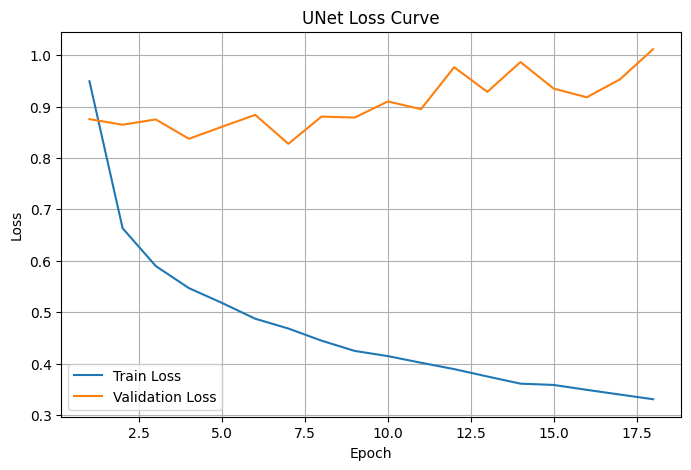

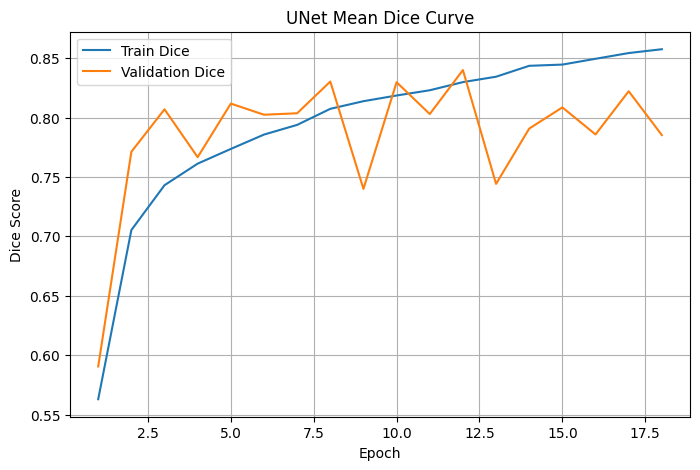

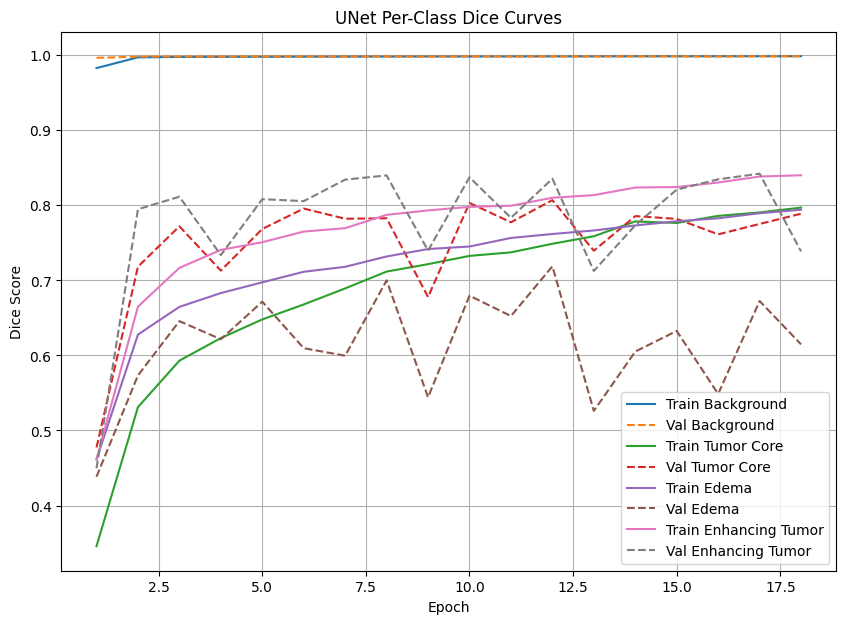

In [ ]:
#graphs plotting
import json
import matplotlib.pyplot as plt
import numpy as np

# Loading history
with open(history_path, "r") as f:
    history = json.load(f)

train_loss = history["train_loss"]
val_loss = history["val_loss"]
train_dice = history["train_mean_dice"]
val_dice = history["val_mean_dice"]

train_pc = np.array(history["train_dice_per_class"])
val_pc = np.array(history["val_dice_per_class"])

epochs = range(1, len(train_loss) + 1)


#  LOSS CURVE
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("UNet Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

#  MEAN DICE CURVE
plt.figure(figsize=(8,5))
plt.plot(epochs, train_dice, label="Train Dice")
plt.plot(epochs, val_dice, label="Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("UNet Mean Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

#  PER-CLASS DICE CURVES
class_names = ["Background", "Tumor Core", "Edema", "Enhancing Tumor"]

plt.figure(figsize=(10,7))
for c in range(4):
    plt.plot(epochs, train_pc[:, c], label=f"Train {class_names[c]}")
    plt.plot(epochs, val_pc[:, c], linestyle="--", label=f"Val {class_names[c]}")

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("UNet Per-Class Dice Curves")
plt.legend()
plt.grid(True)
plt.show()


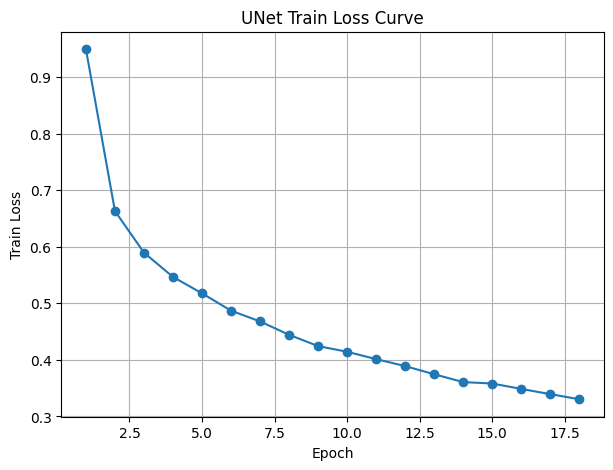

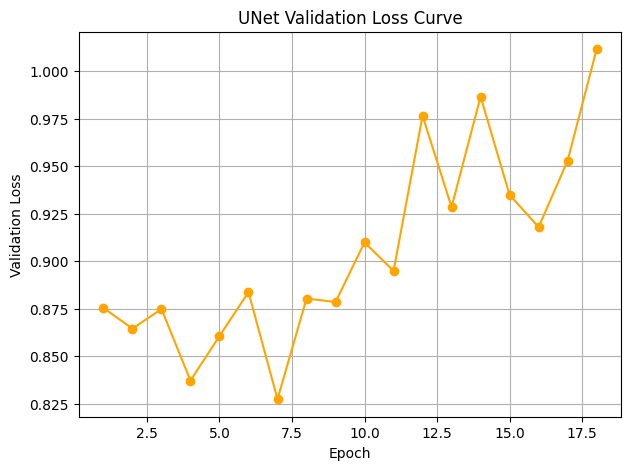

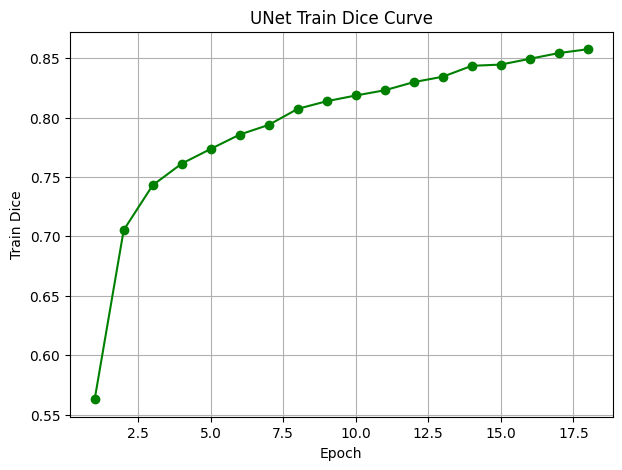

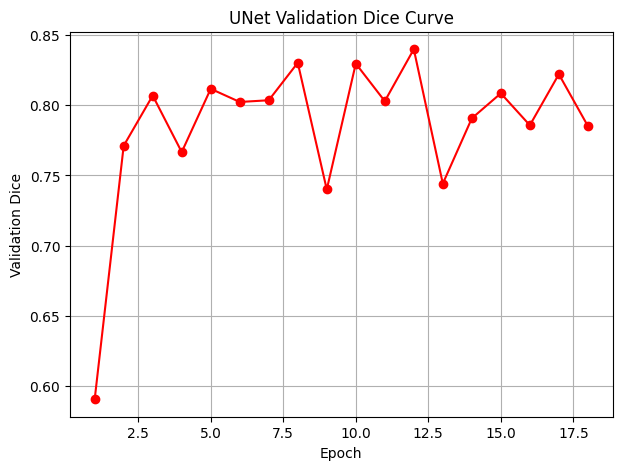

In [ ]:
#seperate plot
import json
import matplotlib.pyplot as plt
history_path= "/content/drive/MyDrive/BratsDataset/testing/checkpoints/UNET_MODEL/unet_history.json"
# Load history
with open(history_path, "r") as f:
    history = json.load(f)

train_loss = history["train_loss"]
val_loss = history["val_loss"]
train_dice = history["train_mean_dice"]
val_dice = history["val_mean_dice"]

epochs = range(1, len(train_loss) + 1)

#  TRAIN LOSS
plt.figure(figsize=(7,5))
plt.plot(epochs, train_loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("UNet Train Loss Curve")
plt.grid(True)
plt.show()

#  VALIDATION LOSS
plt.figure(figsize=(7,5))
plt.plot(epochs, val_loss, marker='o', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("UNet Validation Loss Curve")
plt.grid(True)
plt.show()

#  TRAIN DICE
plt.figure(figsize=(7,5))
plt.plot(epochs, train_dice, marker='o', color='green')
plt.xlabel("Epoch")
plt.ylabel("Train Dice")
plt.title("UNet Train Dice Curve")
plt.grid(True)
plt.show()

#  VALIDATION DICE
plt.figure(figsize=(7,5))
plt.plot(epochs, val_dice, marker='o', color='red')
plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("UNet Validation Dice Curve")
plt.grid(True)
plt.show()


In [ ]:
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader

data_dir = '/content/drive/MyDrive/BratsDataset/testing/processed_data'
test_list = '/content/drive/MyDrive/BratsDataset/testing/splits/test_files.txt'

test_dataset = BraTSSliceDataset(test_list, data_dir)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)
checkpoint_dir = "/content/drive/MyDrive/BratsDataset/testing/checkpoints/UNET_MODEL"
best_model_path = os.path.join(checkpoint_dir, "unet_best.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=4, out_channels=4).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor.to(device))

print("UNet best model loaded successfully!")

test_loss = 0.0
num_batches = 0

dice_sum = torch.zeros(4, device=device)  # 4 classes

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        masks  = masks.to(device).long()

        logits = model(images)
        loss = criterion(logits, masks)

        test_loss += loss.item()
        num_batches += 1

        preds = torch.argmax(logits, dim=1)

        dice_pc, mean_dice = dice_score(preds, masks, num_classes=4)
        dice_sum += dice_pc  # accumulate per-class dice

# Compute Averages

test_loss /= num_batches
dice_avg_per_class = (dice_sum / num_batches).cpu()
mean_test_dice = dice_avg_per_class.mean().item()

class_names = ["Background", "Tumor Core", "Edema", "Enhancing Tumor"]

print("\n UNet TEST RESULTS ")
print(f"Test Loss: {test_loss:.4f}")
print(f"Mean Dice: {mean_test_dice:.4f}")

print("\nPer-Class Dice:")
for c in range(4):
    print(f"  Class {c} ({class_names[c]}): {dice_avg_per_class[c]:.4f}")


UNet best model loaded successfully!


Testing: 100%|██████████| 717/717 [01:53<00:00,  6.31it/s]


 UNet TEST RESULTS 
Test Loss: 0.2993
Mean Dice: 0.8531

Per-Class Dice:
  Class 0 (Background): 0.9986
  Class 1 (Tumor Core): 0.8035
  Class 2 (Edema): 0.7510
  Class 3 (Enhancing Tumor): 0.8594


In [ ]:
#new
# Thesis-quality visualization for 2D BraTS slices (single-channel masks: 0,1,2,3)
# Shows: Input FLAIR | Ground Truth | Prediction | Overlay
# Also optionally saves figures as high-res PNGs.

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm

def visualize_test_predictions_2d(
    model,
    test_loader,
    device=None,
    num_samples=5,
    flair_channel=3,          # 0:T1, 1:T1Gd, 2:T2, 3:FLAIR (common BraTS order)
    save_dir=None,            # e.g. "/content/drive/MyDrive/thesis_figures"
    dpi=300,
    overlay_alpha=0.25,
    only_tumor_slices=True,   # show only slices where GT has tumor
    require_all_regions=False # if True, only show slices that contain classes 1,2,3 in GT
):
    """
    Visualize model predictions on 2D slices for thesis-quality figures.

    Assumptions:
    - images shape per batch: (B, C, H, W)
    - masks shape per batch:  (B, H, W) with classes {0,1,2,3}
    - model output logits:    (B, num_classes, H, W)

    Produces 4-panel figures:
    1) Input FLAIR
    2) Ground Truth mask
    3) Prediction mask
    4) Overlay prediction on FLAIR

    If save_dir is provided, saves PNGs at high DPI.
    """

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model.eval()

    # Colormap: 0=bg (black), 1=TC (red), 2=ED (green), 3=ET (blue)
    cmap = ListedColormap(["black", "red", "green", "blue"])

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    collected = 0
    sample_idx = 0

    print("Collecting representative test slices for visualization...")

    with torch.no_grad():
        for images, masks in tqdm(test_loader):
            images = images.to(device)   # (B, C, H, W)
            masks  = masks.to(device)    # (B, H, W)

            logits = model(images)       # (B, K, H, W)
            preds  = torch.argmax(logits, dim=1)  # (B, H, W)

            # Move to CPU for plotting
            images_cpu = images.detach().cpu()
            masks_cpu  = masks.detach().cpu()
            preds_cpu  = preds.detach().cpu()

            for img, gt, pr in zip(images_cpu, masks_cpu, preds_cpu):
                gt_np = gt.numpy().astype(np.uint8)
                pr_np = pr.numpy().astype(np.uint8)

                # Filter: only slices with tumor in GT
                if only_tumor_slices and not (gt_np > 0).any():
                    continue

                # Optional: require all tumor regions present in GT (1,2,3)
                if require_all_regions:
                    present = set(np.unique(gt_np).tolist())
                    if not {1, 2, 3}.issubset(present):
                        continue

                # Extract FLAIR channel for visualization
                # img shape: (C, H, W)
                if img.ndim != 3:
                    raise ValueError(f"Expected img shape (C,H,W), got {img.shape}")

                if flair_channel >= img.shape[0]:
                    raise ValueError(
                        f"flair_channel={flair_channel} out of range for img with C={img.shape[0]}"
                    )

                flair = img[flair_channel].numpy()

                # Create alpha mask so background stays clean
                pr_alpha = (pr_np > 0).astype(np.float32) * overlay_alpha

                # Plot
                plt.figure(figsize=(16, 4))

                # 1) Input
                plt.subplot(1, 4, 1)
                plt.imshow(flair, cmap="gray")
                plt.title("Input (FLAIR)")
                plt.axis("off")

                # 2) GT
                plt.subplot(1, 4, 2)
                plt.imshow(gt_np, cmap=cmap, vmin=0, vmax=3)
                plt.title("Ground Truth")
                plt.axis("off")

                # 3) Prediction
                plt.subplot(1, 4, 3)
                plt.imshow(pr_np, cmap=cmap, vmin=0, vmax=3)
                plt.title("Prediction")
                plt.axis("off")

                # 4) Overlay
                plt.subplot(1, 4, 4)
                plt.imshow(flair, cmap="gray")
                plt.imshow(pr_np, cmap=cmap, vmin=0, vmax=3, alpha=pr_alpha)
                plt.title("Overlay (Prediction on FLAIR)")
                plt.axis("off")

                plt.tight_layout()

                # Save if requested
                if save_dir is not None:
                    out_path = os.path.join(save_dir, f"qualitative_{sample_idx:03d}.png")
                    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
                plt.show()
                plt.close()

                collected += 1
                sample_idx += 1

                if collected >= num_samples:
                    print(f"Done. Visualized {collected} slices.")
                    return

    print(f"Finished. Visualized {collected} slices (fewer than requested).")


# -------------------------
# Example usage:
# -------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# visualize_test_predictions_2d(
#     model=model,
#     test_loader=test_loader,
#     device=device,
#     num_samples=5,
#     flair_channel=3,
#     save_dir="/content/drive/MyDrive/thesis_figures",  # optional
#     dpi=300,
#     overlay_alpha=0.25,
#     only_tumor_slices=True,
#     require_all_regions=False
# )


Searching for slices with tumor...


100%|██████████| 717/717 [01:54<00:00,  6.26it/s]



Found 2414 slices with tumor.


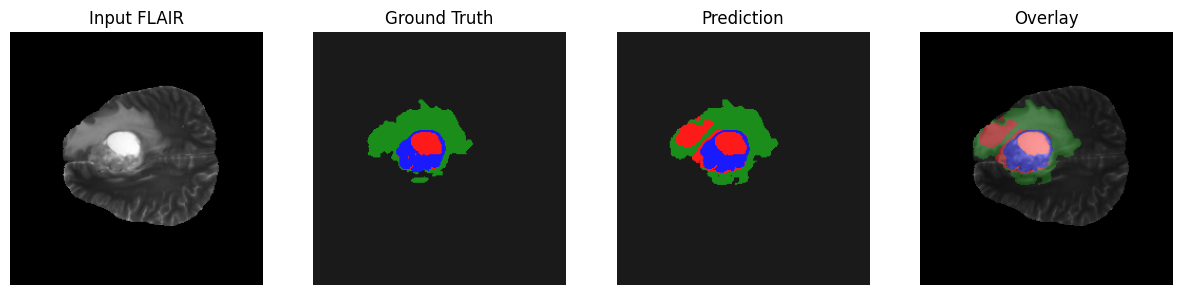

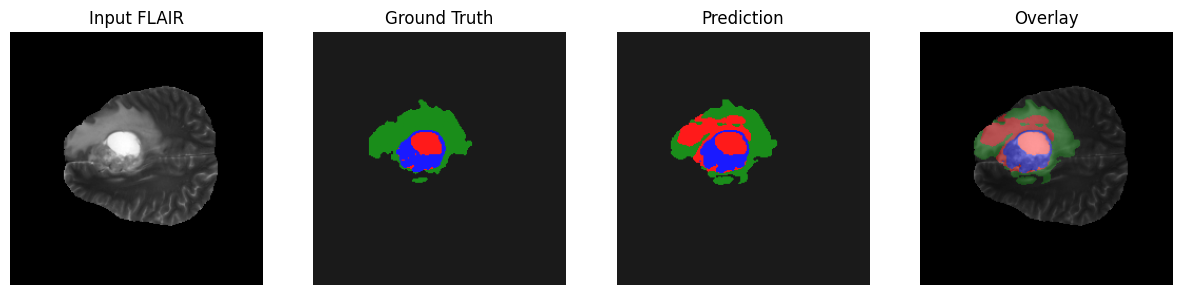

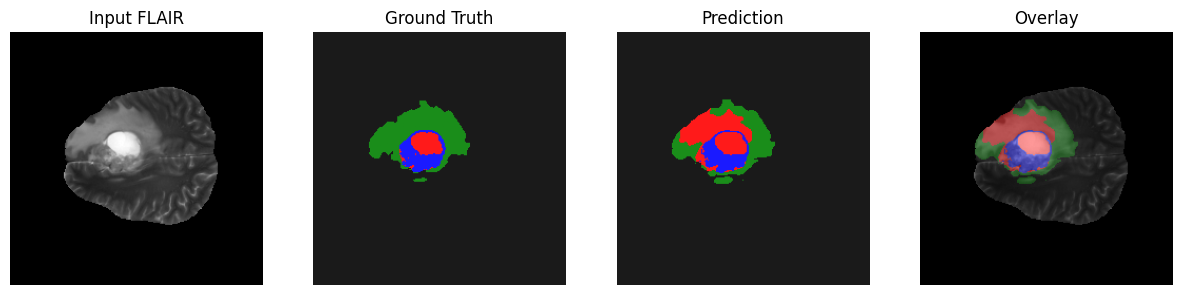

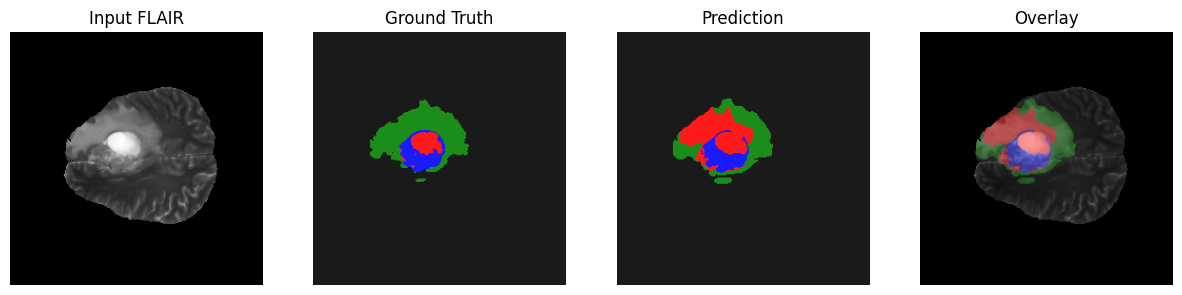

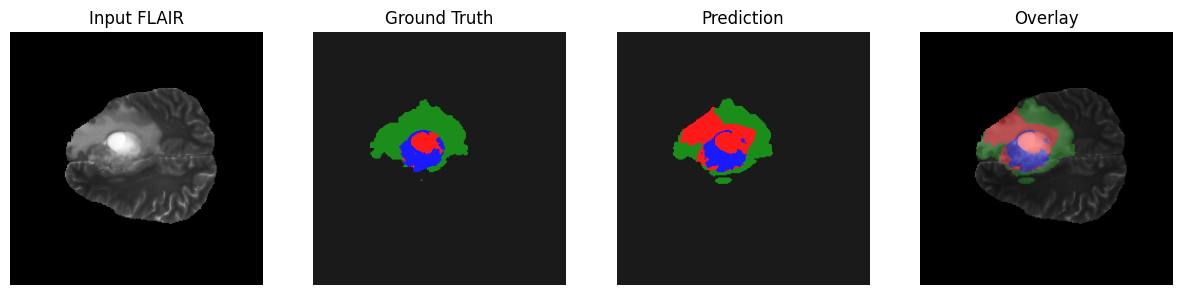

In [ ]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# Color map for mask
cmap = ListedColormap(["black", "red", "green", "blue"])
# 0=bg, 1=TC, 2=ED, 3=ET

tumor_slices = []  # list of (image, mask, pred)

print("Searching for slices with tumor...")
for images, masks in tqdm(test_loader):
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

    # Move to CPU for visualization
    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    # check each slice in batch
    for img, gt, pr in zip(images, masks, preds):
        if (gt > 0).any():            # SLICE HAS TUMOR
            tumor_slices.append((img, gt, pr))

print(f"\nFound {len(tumor_slices)} slices with tumor.")

# ---- Visualize first 5 tumor slices ----
num_show = min(5, len(tumor_slices))

for i in range(num_show):
    img, gt, pr = tumor_slices[i]

    flair = img[3].numpy()                    # FLAIR channel
    gt_mask = gt.numpy()
    pr_mask = pr.numpy()

    plt.figure(figsize=(15,5))

    # input flair
    plt.subplot(1,4,1)
    plt.imshow(flair, cmap="gray")
    plt.title("Input FLAIR")
    plt.axis("off")

    # ground truth
    plt.subplot(1,4,2)
    plt.imshow(gt_mask, cmap=cmap, alpha=0.9)
    plt.title("Ground Truth")
    plt.axis("off")

    # prediction
    plt.subplot(1,4,3)
    plt.imshow(pr_mask, cmap=cmap, alpha=0.9)
    plt.title("Prediction")
    plt.axis("off")

    # overlay
    plt.subplot(1,4,4)
    plt.imshow(flair, cmap="gray")
    plt.imshow(pr_mask, cmap=cmap, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()


Evaluating tumor slices only...


100%|██████████| 717/717 [01:57<00:00,  6.09it/s]



🎯 BEST REAL slice: 1940 Dice= 0.9796815514564514
⚠️ WORST REAL slice: 2134 Dice= 0.24846066534519196


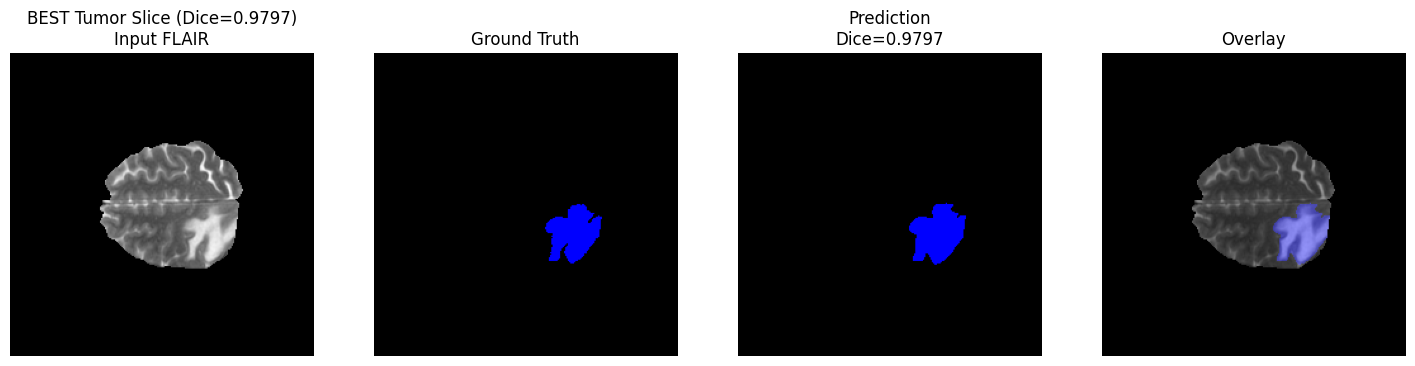

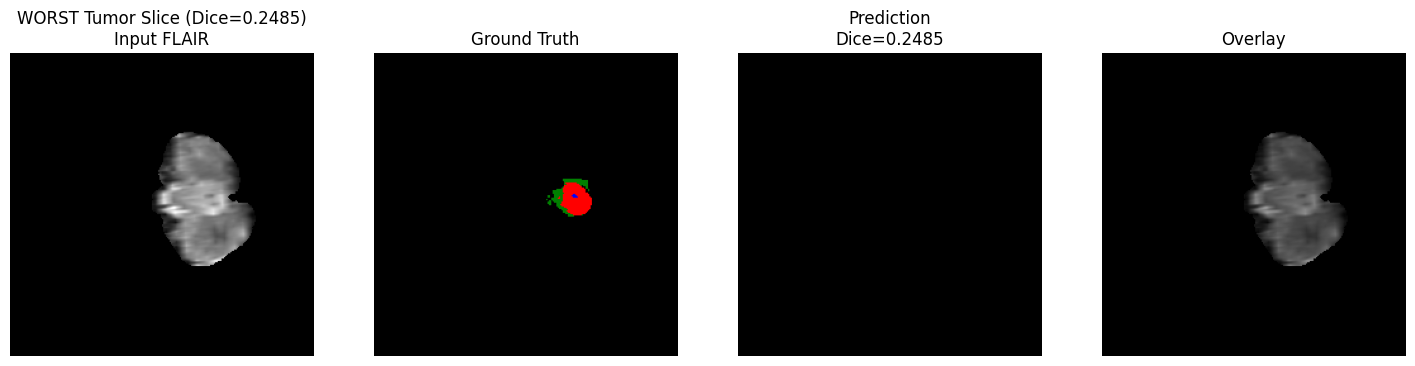

In [ ]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm

checkpoint_dir = "/content/drive/MyDrive/BratsDataset/testing/checkpoints/UNET_MODEL"
best_model_path = os.path.join(checkpoint_dir, "unet_best.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=4, out_channels=4).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

num_classes = 4
cmap = ListedColormap(["black", "red", "green", "blue"])

def dice_single(pred, true, eps=1e-6):
    dice_scores = []
    for cls in range(num_classes):
        p = (pred == cls).float()
        t = (true == cls).float()

        inter = (p * t).sum()
        union = p.sum() + t.sum()

        if union == 0:
            # ignore empty classes → do NOT return 1.0
            continue
        dice_scores.append((2 * inter + eps) / (union + eps))

    if len(dice_scores) == 0:
        return None   # ignore empty slice completely

    return float(sum(dice_scores) / len(dice_scores))

# ------------------------------------------------------------------

all_images, all_masks, all_preds, all_dice = [], [], [], []

print("Evaluating tumor slices only...")

for images, masks in tqdm(test_loader):
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        preds = torch.argmax(model(images), dim=1)

    images, masks, preds = images.cpu(), masks.cpu(), preds.cpu()

    for img, gt, pr in zip(images, masks, preds):

        # Skip slices with **no tumor**
        if (gt > 0).sum() < 50:   # ignore very small tumor (<50 pixels)
            continue

        d = dice_single(pr, gt)
        if d is None:
            continue

        all_images.append(img)
        all_masks.append(gt)
        all_preds.append(pr)
        all_dice.append(d)

# Convert to tensor
all_dice = torch.tensor(all_dice)

# Find meaningful best & worst slices
best_idx = torch.argmax(all_dice).item()
worst_idx = torch.argmin(all_dice).item()

best_dice = all_dice[best_idx].item()
worst_dice = all_dice[worst_idx].item()

print("\n🎯 BEST REAL slice:", best_idx, "Dice=", best_dice)
print("⚠️ WORST REAL slice:", worst_idx, "Dice=", worst_dice)

def visualize(idx, title):
    img = all_images[idx][3].numpy()
    gt  = all_masks[idx].numpy()
    pr  = all_preds[idx].numpy()

    plt.figure(figsize=(18,5))

    plt.subplot(1,4,1)
    plt.imshow(img, cmap="gray")
    plt.title(title + "\nInput FLAIR")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(gt, cmap=cmap)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(pr, cmap=cmap)
    plt.title(f"Prediction\nDice={all_dice[idx]:.4f}")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(img, cmap="gray")
    plt.imshow(pr, cmap=cmap, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

# Show improved good & bad slices
visualize(best_idx, f"BEST Tumor Slice (Dice={best_dice:.4f})")
visualize(worst_idx, f"WORST Tumor Slice (Dice={worst_dice:.4f})")


In [ ]:
import torch
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()


# WT = whole tumor = 1,2,3
# TC = tumor core = 1,3
# ET = enhancing tumor = 3

regions = {
    "WT": [1, 2, 3],
    "TC": [1, 3],
    "ET": [3]
}

def compute_confusion(pred, true):
    TP = ((pred == 1) & (true == 1)).sum().item()
    FP = ((pred == 1) & (true == 0)).sum().item()
    FN = ((pred == 0) & (true == 1)).sum().item()
    TN = ((pred == 0) & (true == 0)).sum().item()
    return TP, FP, FN, TN

def dice(TP, FP, FN, eps=1e-6):
    return (2*TP + eps) / (2*TP + FP + FN + eps)

def iou(TP, FP, FN, eps=1e-6):
    return (TP + eps) / (TP + FP + FN + eps)

def precision(TP, FP, eps=1e-6):
    return (TP + eps) / (TP + FP + eps)

def recall(TP, FN, eps=1e-6):
    return (TP + eps) / (TP + FN + eps)   # also sensitivity

def specificity(TN, FP, eps=1e-6):
    return (TN + eps) / (TN + FP + eps)


metrics = {
    "WT": {"TP":0, "FP":0, "FN":0, "TN":0},
    "TC": {"TP":0, "FP":0, "FN":0, "TN":0},
    "ET": {"TP":0, "FP":0, "FN":0, "TN":0},
}

print("Computing metrics over test set...")

for images, masks in tqdm(test_loader):
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        preds = torch.argmax(model(images), dim=1)

    preds = preds.cpu()
    masks = masks.cpu()

    for region_name, region_labels in regions.items():

        # Binarize GT and prediction
        gt_bin = torch.isin(masks, torch.tensor(region_labels))
        pr_bin = torch.isin(preds, torch.tensor(region_labels))

        # Compute confusion matrix
        TP, FP, FN, TN = compute_confusion(pr_bin, gt_bin)

        metrics[region_name]["TP"] += TP
        metrics[region_name]["FP"] += FP
        metrics[region_name]["FN"] += FN
        metrics[region_name]["TN"] += TN



print("\n FINAL TEST METRICS ")

for region_name in ["WT", "TC", "ET"]:
    TP = metrics[region_name]["TP"]
    FP = metrics[region_name]["FP"]
    FN = metrics[region_name]["FN"]
    TN = metrics[region_name]["TN"]

    dsc = dice(TP, FP, FN)
    jacc = iou(TP, FP, FN)
    prec = precision(TP, FP)
    rec = recall(TP, FN)
    spec = specificity(TN, FP)

    print(f"\n------ {region_name} ------")
    print(f"Dice Score     : {dsc:.4f}")
    print(f"IoU (Jaccard)  : {jacc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall         : {rec:.4f}")
    print(f"Specificity    : {spec:.4f}")


Computing metrics over test set...


100%|██████████| 717/717 [02:31<00:00,  4.74it/s]


 FINAL TEST METRICS 

------ WT ------
Dice Score     : 0.8852
IoU (Jaccard)  : 0.7940
Precision      : 0.8315
Recall         : 0.9463
Specificity    : 0.9978

------ TC ------
Dice Score     : 0.8739
IoU (Jaccard)  : 0.7760
Precision      : 0.8509
Recall         : 0.8981
Specificity    : 0.9993

------ ET ------
Dice Score     : 0.8597
IoU (Jaccard)  : 0.7540
Precision      : 0.8048
Recall         : 0.9228
Specificity    : 0.9995


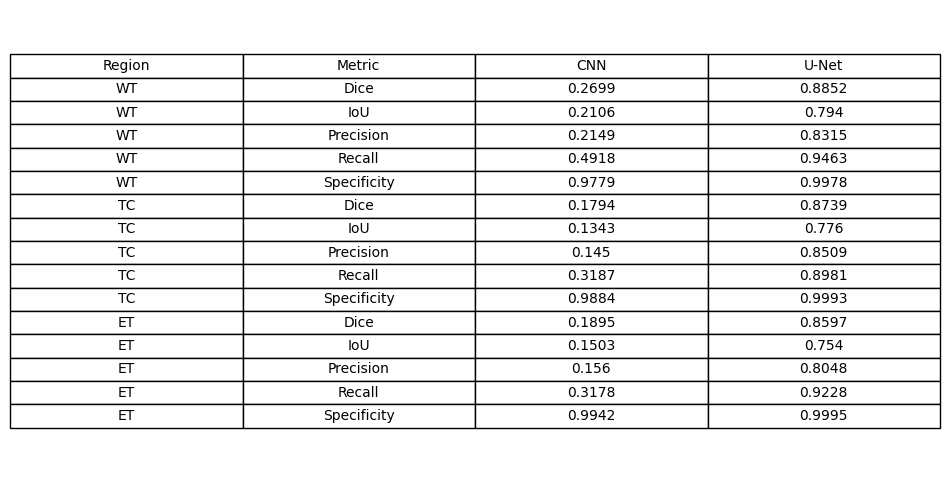

Saved comparison table as PNG!


In [ ]:
# comparison tabe of cnn and unet
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    "Region": [
        "WT", "WT", "WT", "WT", "WT",
        "TC", "TC", "TC", "TC", "TC",
        "ET", "ET", "ET", "ET", "ET"
    ],
    "Metric": [
        "Dice", "IoU", "Precision", "Recall", "Specificity"
    ] * 3,
    "CNN": [
        0.2699, 0.2106, 0.2149, 0.4918, 0.9779,
        0.1794, 0.1343, 0.1450, 0.3187, 0.9884,
        0.1895, 0.1503, 0.1560, 0.3178, 0.9942
    ],
    "U-Net": [
        0.8852, 0.7940, 0.8315, 0.9463, 0.9978,
        0.8739, 0.7760, 0.8509, 0.8981, 0.9993,
        0.8597, 0.7540, 0.8048, 0.9228, 0.9995
    ]
}

df = pd.DataFrame(data)

# Plot as table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)

plt.savefig("/content/cnn_unet_comparison_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved comparison table as PNG!")


In [ ]:
!pip install medpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.4 MB/s eta 0:00:00
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=13334274c1d00bf1b2f49a4e693c86fce49bad3b05f4f36cb9ef5f338809d116
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


In [ ]:
#calculate hausdorff distance
import torch
import numpy as np
from tqdm import tqdm
from medpy.metric.binary import hd95

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- REGION DEFINITIONS -----
regions = {
    "WT": [1, 2, 3],  # Whole Tumor
    "TC": [1, 3],     # Tumor Core
    "ET": [3]         # Enhancing Tumor
}

def to_region_mask(mask, region_classes):
    """
    Convert class mask into binary region mask.
    """
    mask_np = mask.cpu().numpy()
    return np.isin(mask_np, region_classes).astype(np.uint8)

def safe_hd95(pred_mask, true_mask):
    """
    Compute HD95 but gracefully handle cases where mask is empty.
    """
    if pred_mask.sum() == 0 and true_mask.sum() == 0:
        return 0.0  # perfect match when both are empty

    if pred_mask.sum() == 0 or true_mask.sum() == 0:
        return np.nan  # undefined (model missed tumor entirely)

    return hd95(pred_mask, true_mask)

# --------- Compute HD95 Across Test Set ---------
hd_scores = {r: [] for r in regions.keys()}
checkpoint_dir = "/content/drive/MyDrive/BratsDataset/testing/checkpoints/UNET_MODEL"
best_model_path = os.path.join(checkpoint_dir, "unet_best.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=4, out_channels=4).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("Computing HD95...")

for images, masks in tqdm(test_loader):
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

    for pr, gt in zip(preds, masks):

        for region_name, region_classes in regions.items():

            pr_bin = to_region_mask(pr, region_classes)
            gt_bin = to_region_mask(gt, region_classes)

            dist = safe_hd95(pr_bin, gt_bin)
            if not np.isnan(dist):
                hd_scores[region_name].append(dist)

# --------- Compute Mean HD95 Per Region ----------
final_hd95 = {r: float(np.mean(hd_scores[r])) for r in regions.keys()}

print("\n-------- FINAL HD95 RESULTS --------")
for region in final_hd95:
    print(f"{region}: HD95 = {final_hd95[region]:.4f} pixels")


Computing HD95...


100%|██████████| 717/717 [02:40<00:00,  4.47it/s]


-------- FINAL HD95 RESULTS --------
WT: HD95 = 4.6576 pixels
TC: HD95 = 2.1694 pixels
ET: HD95 = 1.2164 pixels
